# Assignment: Linear and logistic regression

## Objectives

The objectives of this assignment are:
1. to learn to use linear regression for predicting continuously varying target variables 
2. to learn to use logistic regression for binary classification
3. to learn to estimate the relative importance of input features

## Setup

In this assignment, use the Real Estate Valuation dataset that is available at [https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set). The data is collected from New Taipei City, Taiwan. 

## Task

The assignment consists of constructing *two* separate models for predicting the real estate prices in the dataset: one with linear and one with logistic regression.

1. **Linear regression model**: construct a linear regression model for predicting the continuous target variable "Y house price of unit area" in the dataset.

2. **Logistic regression model**: convert the target variable into a binary-valued one according to whether the original target value is above or below the average house price of unit area (within the training set samples), and construct a binary classifier for predicting its value with logistic regression.

Both models should be validated, with appropriate metrics presented and discussed. 

Remember to draw conclusions from your results and interpret your findings! Can you e.g. estimate which of the input variables has the most important role when predicting the house prices, and which ones are less important? Also, give some thought to whether the input data should be standardized before modeling or not. 

Prepare a Jupyter notebook containing a full account of the problem treatment. Construct your notebook to include sections for each of the six separate stages in the CRISP-DM model, with appropriate contents (include subsections for the two separate tasks in "Modeling" and "Evaluation").

## Deliverables

Submit a GitHub permalink that points to the Jupyter notebook as instructed in Oma. The submitted notebook must contain the problem analysis written in accordance with the CRISP-DM process model, complete with Markdown blocks and comments that clearly explain what has been done. 



## CRISP-DM
This notebook follows the CRISP-DM process model

CRISP-DM phases:

1. Business understanding: The first phase is to understand the business problem that needs to be solved. What is the goal of the analysis? What are the requirements and constraints? What is the expected outcome?

2. Data understanding: The second phase is to collect and explore the data. What data is available? What are the characteristics of the data (variable types, value distributions etc.)? Are there any quality issues with the data (missing values, outliers, nonsensical values)?

3. Data preparation: The third phase is to preprocess the data. This includes cleaning the data, transforming the data, and selecting the relevant features. These steps should be documented in such detail that they can be reproduced later.

4. Modeling: The fourth phase is to choose a machine learning method and train the model. This phase also includes the validation of the model. Documentation needs include: which method was used, which parameters were used, what was the performance of the model?

5. Evaluation: The fifth phase is to evaluate the model. How well does the model perform? Does it meet the business requirements?

6. Deployment: The final phase is to deploy the model. How will the model be used in practice? How will the results be communicated? This phase may involve creating a recommendation of how to use the model in practice, or what to do next.


## 1. Business understanding

Goal of this project is to build machine learning models to predict real estate prices in **New Taipei City, Taiwan** using easily obtainable property and location characteristics.


The project involves making two separate models:

1. **Linear regression model** to predict the continuous target variable "Y house price unit area."

2. **Logistic regression model** to predict whether a property's price per unit area is above average (1) or below average (0) within the training set samples.


## 2. Data understanding

## 2.1 Importing the data
The dataset contains real estate valuations from Sindian Dist., New Taipei City, Taiwan, including Transaction Date, House Age, Distance to the nearest MRT station, number of convenience stores, location based on latitude and longitude and house prive of unit are.


In [493]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
from pandas import DataFrame
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)


# Data
features : DataFrame = real_estate_valuation.data.features
targets : DataFrame = real_estate_valuation.data.targets

# Metadata and variables info
metadata : DataFrame = real_estate_valuation.metadata
variables : DataFrame = real_estate_valuation.variables

# Dynamically extract target column name to prevent KeyError
target_col = targets.columns[-1]

print(f"Dataset Shape: {features.shape[0]} samples, {features.shape[1]} features")
#print(f"\nClass Distribution in '{target_col}' (10000 New Taiwan Dollar/Ping):")
# print(targets[target_col].value_counts())


# Check for missing values
print("\nMissing Values Check (Features):")
print(features.isnull().sum())
print("\nMissing Values Check (Targets):")
print(targets.isnull().sum())

# Summary statistics for features
print("\nFeatures Summary Statistics:")
display(features.describe().T[["mean", "std", "min", "50%", "max"]])

# Summary statistics for target variable
print(f"\nTarget Summary ('{target_col}'):")
display(targets.describe())

Dataset Shape: 414 samples, 6 features

Missing Values Check (Features):
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
dtype: int64

Missing Values Check (Targets):
Y house price of unit area    0
dtype: int64

Features Summary Statistics:


,mean,std,min,50%,max
X1 transaction date,2013.148971,0.281967,2012.66700,2013.16700,2013.58300
X2 house age,17.712560,11.392485,0.00000,16.10000,43.80000
X3 distance to the nearest MRT station,1083.885689,1262.109595,23.38284,492.23130,6488.02100
X4 number of convenience stores,4.094203,2.945562,0.00000,4.00000,10.00000
X5 latitude,24.969030,0.012410,24.93207,24.97110,25.01459
X6 longitude,121.533361,0.015347,121.47353,121.53863,121.56627



Target Summary ('Y house price of unit area'):


,Y house price of unit area
count,414.000000
mean,37.980193
std,13.606488
min,7.600000
25%,27.700000
50%,38.450000
75%,46.600000
max,117.500000


# 2.2 Features & Metadata

In [494]:
# Example of X-axis data which represnt X inputs
features.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,2012.917,32.0,84.87882,10,24.98298,121.54024
1,2012.917,19.5,306.59470,9,24.98034,121.53951
2,2013.583,13.3,561.98450,5,24.98746,121.54391
3,2013.500,13.3,561.98450,5,24.98746,121.54391
4,2012.833,5.0,390.56840,5,24.97937,121.54245


In [495]:
# Example of Y-axis data which represnt Y outputs
targets.head()

,Y house price of unit area
0,37.9
1,42.2
2,47.3
3,54.8
4,43.1


In [496]:
# Metadata
metadata

{'uci_id': 477,
 'name': 'Real Estate Valuation',
 'repository_url': 'https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set',
 'data_url': 'https://archive.ics.uci.edu/static/public/477/data.csv',
 'abstract': 'The real estate valuation is a regression problem. The market historical data set of real estate valuation are collected from Sindian Dist., New Taipei City, Taiwan. ',
 'area': 'Business',
 'tasks': ['Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 414,
 'num_features': 6,
 'feature_types': ['Integer', 'Real'],
 'demographics': [],
 'target_col': ['Y house price of unit area'],
 'index_col': ['No'],
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 2018,
 'last_updated': 'Mon Feb 26 2024',
 'dataset_doi': '10.24432/C5J30W',
 'creators': ['I-Cheng Yeh'],
 'intro_paper': {'ID': 373,
  'type': 'NATIVE',
  'title': 'Building real estate valuation models with comparative approach through case-based reason

## 2.3 Variables

The dataset should not have any missing variables.

In [497]:
# Variable information
variables

,name,role,type,demographic,description,units,missing_values
0,No,ID,Integer,None,NaN,NaN,no
1,X1 transaction date,Feature,Continuous,None,"for example, 2013.250=2013 March, 2013.500=201...",NaN,no
2,X2 house age,Feature,Continuous,None,NaN,year,no
3,X3 distance to the nearest MRT station,Feature,Continuous,None,NaN,meter,no
4,X4 number of convenience stores,Feature,Integer,None,number of convenience stores in the living cir...,integer,no
5,X5 latitude,Feature,Continuous,None,"geographic coordinate, latitude",degree,no
6,X6 longitude,Feature,Continuous,None,"geographic coordinate, longitude",degree,no
7,Y house price of unit area,Target,Continuous,None,"10000 New Taiwan Dollar/Ping, where Ping is a ...",10000 New Taiwan Dollar/Ping,no


## 2.4 Data Understanding: Summary

- The dataset contains 414 total instances.
- There are **6 features** (X1 to X6) and **1 target variable** (Y house price of unit area). Including the index/ID column ('No'), this makes a total of **8 variables** per entry.
- The ID column and the 'Number of convenience stores' (X4) are integers. The remaining variables (transaction date, house age, distance to MRT, latitude, longitude, and house price) are floats.
- There are no nulls in this dataset, meaning we do not need to drop rows or impute missing data.
- Because each feature has its own distinct units and scale (e.g., years for age, meters for distance, degrees for coordinates), applying feature scaling (like standardization or normalization) will be important to ensure models process the data evenly.


## 2.5 Data Understanding: Conclusions

The dataset contains 414 observations and six input features for predicting the house price of a unit area. The target variable is continuous, making it suitable for the linear regression task.

There are no missing values in either the feature variables or the target variable, so no missing-value imputation is required.

The features have very different numerical scales. For example, the distance to the nearest MRT station has values in the thousands, while latitude and longitude vary only by small decimal amounts. Therefore, standardization is useful, especially when comparing the relative importance of model coefficients and when training logistic regression.

The descriptive statistics also show that the input variables have different distributions and ranges. The target variable has a mean of approximately 37.98 and a standard deviation of approximately 13.61.

Overall, the dataset is suitable for both regression and binary classification. The main preparation requirement is to separate the training and test data and standardize the input features using statistics learned only from the training data.


## 3. Data Preparation


## 3.1 Separating training and testing data

In [498]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# confirm that no null entries actually exist
assert features.notna().all().all()
assert targets.notna().all().all()

# Hold-out validation split
features_train, features_test, target_train, target_test = train_test_split(
    features, 
    targets, 
    test_size=0.25, 
    random_state=69
)

# Scale features
scaler = StandardScaler()
# Fit the scaler on training data only to learn its mean and variance
scaled_features_train = pd.DataFrame(scaler.fit_transform(features_train), columns=features.columns)
# Scale features_test using the exact same mean and variance learned from features_train
scaled_features_test = pd.DataFrame(scaler.transform(features_test), columns=features.columns)


# assert the list sizes
assert len(features_train) == len(target_train) and len(features_test) == len(target_test)

print("Data Preparation Completed:")
print(f"Training set size: {features_train.shape[0]} samples.")
print(f"Testing set size: {features_test.shape[0]} samples.")

print("---------------------------------------")
print("1. Without standardize features train data :")
display(features_train.head(5)) 

print("---------------------------------------")
print("2. With standardize features train data (for the Logistic regression) :")
display(scaled_features_train.head(5)) 


Data Preparation Completed:
Training set size: 310 samples.
Testing set size: 104 samples.
---------------------------------------
1. Without standardize features train data :


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
133,2012.833,18.0,373.3937,8,24.98660,121.54082
302,2013.500,16.5,2288.0110,3,24.95885,121.51359
393,2013.000,16.9,967.4000,4,24.98872,121.53408
63,2013.583,2.6,533.4762,4,24.97445,121.54765
243,2013.417,32.8,204.1705,8,24.98236,121.53923


---------------------------------------
2. With standardize features train data (for the Logistic regression) :


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
0,-1.128466,-0.020088,-0.579068,1.403480,1.476409,0.501728
1,1.260062,-0.150917,0.875657,-0.324395,-0.759358,-1.216142
2,-0.530439,-0.116029,-0.127743,0.021180,1.647214,0.076519
3,1.557285,-1.363259,-0.457438,0.021180,0.497506,0.932615
4,0.962839,1.270751,-0.707644,1.403480,1.134800,0.401419


### 3.2 Interpretation

The dataset was divided into training and testing sets using a 75/25 split. This resulted in 310 training samples and 104 testing samples.

The training set is used to learn the model parameters, while the test set is kept separate and is only used for evaluating the final models.

The input features were standardized using `StandardScaler`. Importantly, the scaler was fitted only on the training data. The same transformation was then applied to the test data. This prevents information from the test set from influencing the preprocessing step.

Standardization is particularly useful for logistic regression because the input variables have very different numerical scales. It also makes the coefficients of the linear regression model more comparable because the features are expressed on the same standardized scale.


## 4. Modeling

### 4.1 Baseline model

#### 4.1.1 Linear

In [499]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(scaled_features_train, target_train)

# Extract the scalar intercept
b0 = model.intercept_.item()

# Extract the array of 6 coefficients and flatten it for printing
coefficients = model.coef_.ravel()

print(f"Intercept: {b0:.2f}")
print(f"Coefficients:")
for c in coefficients:
    print(f"{c:.5f}")

Intercept: 36.95
Coefficients:
1.08934
-3.00300
-5.67787
2.75896
3.32115
-0.32060


#### 4.1.1.1 Mathematical Formulation of the Linear Model

Before training the model, we define the mathematical framework for our multi-feature regression task.

**1. Hypothesis Function $h(x)$:**
The model estimates the real-world target variable ($Y$ house price of unit area) by taking a linear combination of all **6** input **features**:
$$h(x) = b_0 + b_1X_1 + b_2X_2 + b_3X_3 + b_4X_4 + b_5X_5 + b_6X_6$$
Where $b_1 \dots b_6$ are the feature weights (coefficients) and $b_0$ is the bias (intercept). In a real-world context, a feature like $X_3$ (distance to MRT) is expected to carry a heavy negative weight, as proximity to transit strongly drives property values.

**2. Cost Function (Mean Squared Error - MSE):**
To measure the average squared difference between the actual values ($y$) and the predicted outputs from $h(x)$, the model optimizes its weights using the Mean Squared Error (MSE) loss function:
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (h(x^{(i)}) - y^{(i)})^2$$ 

**3. Evaluation Metrics:**
To fully assess the performance of the trained model on the test dataset, we compute three standard evaluation metrics derived from the core mathematical framework:
* Coefficient of Determination ($R^2$ Score): Measures the proportion of variance in the target variable that is predictable from the independent variables. It indicates the global efficiency and "intelligence" of the hypothesis function $h(x)$:
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y^{(i)} - h(x^{(i)}))^2}{\sum_{i=1}^{n} (y^{(i)} - \bar{y})^2}$$

* Root Mean Squared Error (RMSE): The square root of the Mean Squared Error. It penalizes larger errors more heavily due to the squaring operation, acting as a strict quality metric for the model's global distances:
$$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (h(x^{(i)}) - y^{(i)})^2}$$


* Mean Absolute Error (MAE): Measures the average magnitude of the errors in a set of predictions, without considering their direction. It represents the actual average error magnitude directly in real-world price units:
$$MAE = \frac{1}{n} \sum_{i=1}^{n} \left\vert{} h(x^{(i)}) - y^{(i)} \right\vert{}$$ 



### Linear Regression Model Evaluation: Actual vs. Predicted Prices

To evaluate the performance of our Linear Regression model, we calculate the standard evaluation metrics ($R^2$, MSE, and MAE) on the test dataset. Additionally, we generate an "Actual vs. Predicted" scatter plot. This visualization helps us assess how closely the model's final predictions (which account for all 6 features simultaneously) align with the true real estate prices. Points closer to the diagonal red line represent highly accurate predictions.


h(x) R2 Score: 0.5716
MSE: 81.6980
MAE: 6.7069


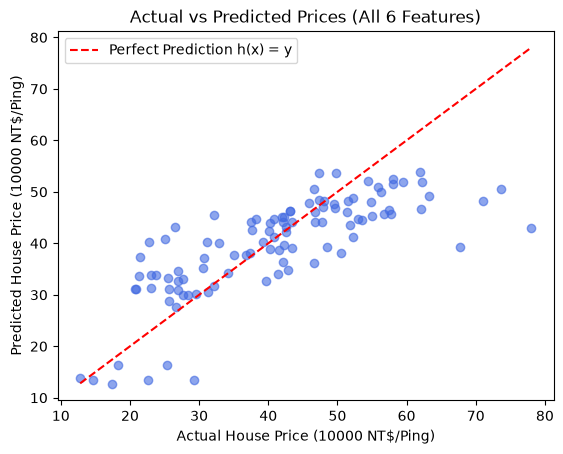

In [500]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Calculate hypothesis function outputs
# h(x) = b0 + b1X1 + b2X2 + ... + b6X6
h_x_predictions = model.predict(scaled_features_test)

# 2. Calculate evaluation metrics mapping to the mathematical framework

# Proportion of price variance (measures the efficiency of the hypothesis function h(x))
# y^(i) = target_test
r2 = r2_score(target_test, h_x_predictions)

# Cost Function: Mean Squared Error (RMSE)
rmse = mean_squared_error(target_test, h_x_predictions)

# Mean Absolute Error (MAE) in actual price units
mae = mean_absolute_error(target_test, h_x_predictions)

# 3. Print the evaluation metrics
print(f"h(x) R2 Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")

# 4. Generate Actual vs. Predicted scatter plot
plt.scatter(target_test, h_x_predictions, alpha=0.6, color='royalblue')
min_val = target_test.min().item()
max_val = target_test.max().item()
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction h(x) = y')

# Labels
plt.xlabel('Actual House Price (10000 NT$/Ping)')
plt.ylabel('Predicted House Price (10000 NT$/Ping)')
plt.title('Actual vs Predicted Prices (All 6 Features)')
plt.legend()
plt.show()


### Exploratory Data Analysis: Individual Feature Relationships

To understand how each of the 6 independent variables impacts the target variable (`Y house price of unit area`), we generate individual regression plots (subplots) for each feature. This visual analysis helps identify linear trends, potential outliers, and the overall correlation strength before feeding the standardized data into our machine learning models.


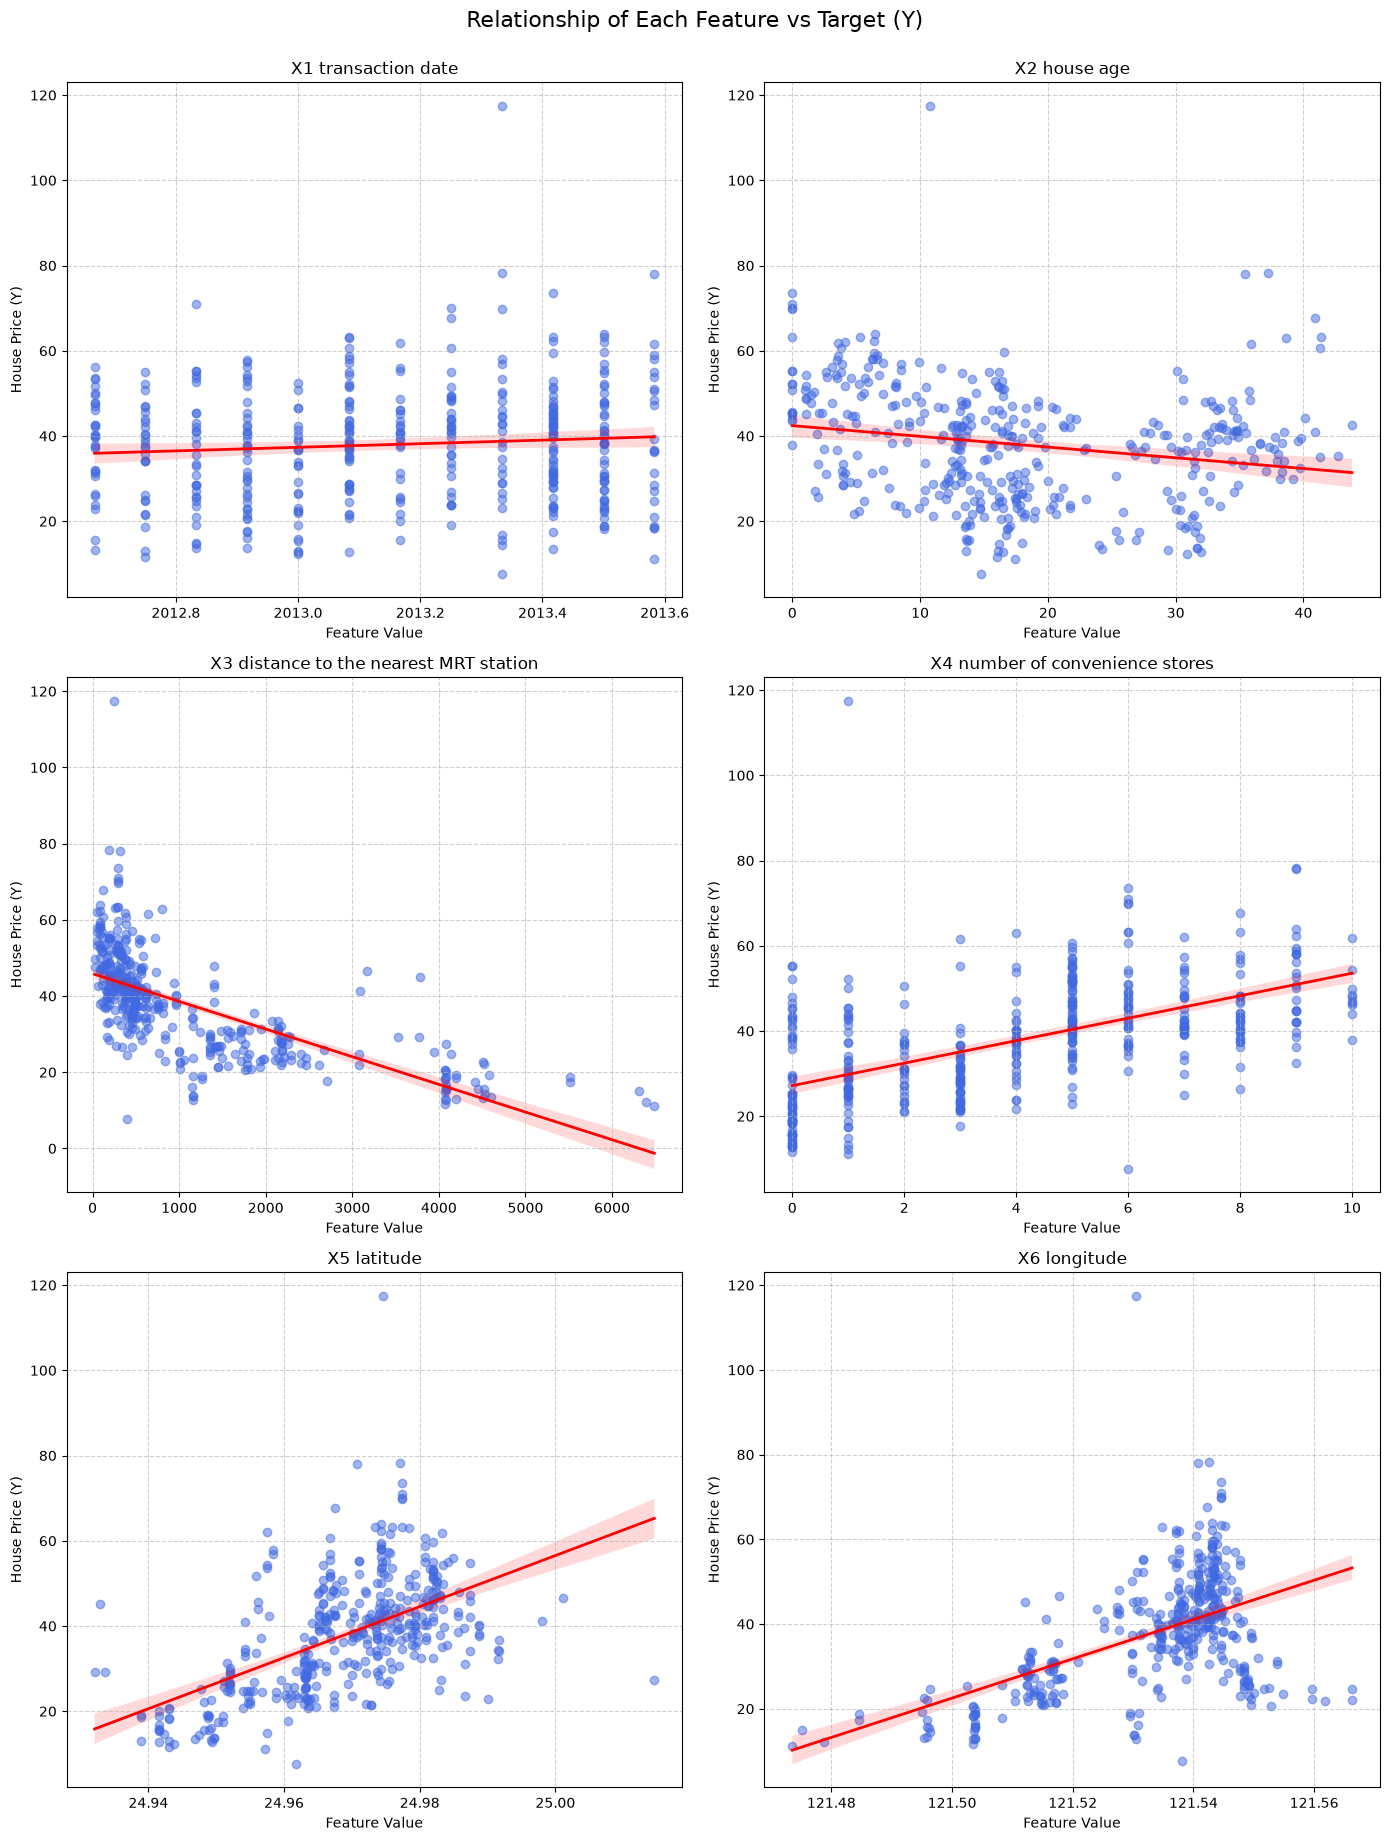

In [501]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup the figure grid with 3 rows and 2 columns for the 6 subplots
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 18))

# Flatten the 2D axes array into a 1D list for easier looping
axes = axes.flatten()

# 2. Iterate through all 6 features and generate a regression plot for each
for i, col in enumerate(features.columns):
    sns.regplot(
        x=features[col], 
        y=targets[target_col], 
        ax=axes[i],
        scatter_kws={'alpha':0.5, 'color': 'royalblue'}, # Set point transparency and color
        line_kws={'color': 'red', 'linewidth': 2}        # Set regression line color and thickness
    )
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Feature Value')
    axes[i].set_ylabel('House Price (Y)')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 3. Adjust spacing between subplots to prevent text overlapping
plt.tight_layout()
plt.suptitle('Relationship of Each Feature vs Target (Y)', fontsize=16, y=1.02)
plt.show()

#### 4.1.2 Logistic, without stantardization

In [502]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# Calculate the average price in the training set
average_price = target_train.mean().item()

# Create the binary target: 1 if > average, 0 if <= average
binary_target_train = (target_train > average_price).astype(int)
binary_target_test = (target_test > average_price).astype(int)

# Build and fit the model
"""
reg = LogisticRegression(solver='lbfgs')
reg.fit(features_train, binary_target_train.squeeze())
print(f"Intercept: {b0:.2f}")
print(f"Coefficients:")
for c in coefficients:
    print(f"{c:.5f}")
"""

log_reg = LogisticRegression(random_state=0,
                             C = 1.0,
                             fit_intercept=True,
                             ).fit(features_train, binary_target_train.squeeze())

train_acc = log_reg.score(features_train, binary_target_train)
test_acc = log_reg.score(features_test, binary_target_test)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}\n")

Train Accuracy: 0.8387
Test Accuracy: 0.8654



Precision: 0.9194
Recall: 0.8636



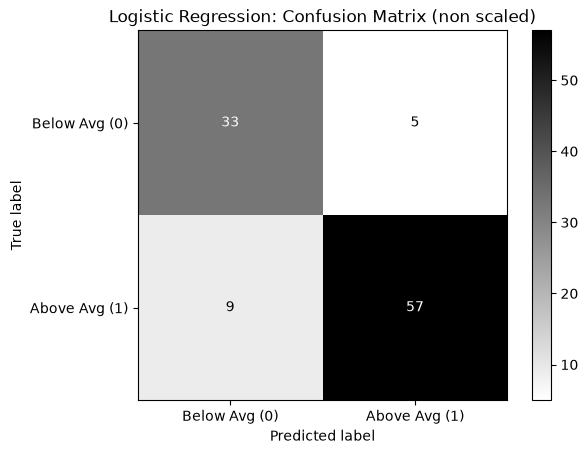

In [503]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score

# Generate binary predictions
predictions_logistic = log_reg.predict(features_test)

# Calculate and print Precision and Recall
precision = precision_score(binary_target_test, predictions_logistic)
recall = recall_score(binary_target_test, predictions_logistic)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}\n")

# Create the confusion matrix
# compute confusion matrix agaisnt TEST labels
cm = confusion_matrix(binary_target_test, predictions_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Below Avg (0)', 'Above Avg (1)'])

disp.plot(cmap='binary')

plt.title('Logistic Regression: Confusion Matrix (non scaled)')
plt.show()


#### 4.1.3 Logistic, with stantardization

In [504]:
from sklearn.linear_model import LogisticRegression
import numpy as np

"""
# Calculate the average price in the training set
average_price = scaled_target_train.mean().item()

# Create the binary target: 1 if > average, 0 if <= average
binary_target_train = (scaled_target_train > average_price).astype(int)

# Build and fit the model 
reg = LogisticRegression(solver='lbfgs')
reg.fit(scaled_features_train, binary_target_train.squeeze())

print(f"Intercept: {b0:.2f}")
print(f"Coefficients:")
for c in coefficients:
    print(f"{c:.5f}")
"""

scaler = StandardScaler()

# Standardize features
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

log_reg1 = LogisticRegression(random_state=0,
                             C = 1.0,
                             fit_intercept=True,
                             ).fit(features_train_scaled, binary_target_train.squeeze())

train_acc1 = log_reg1.score(features_train_scaled, binary_target_train)
test_acc1 = log_reg1.score(features_test_scaled, binary_target_test)


print(f"Train Accuracy: {train_acc1:.4f}")
print(f"Test Accuracy: {test_acc1:.4f}\n")


Train Accuracy: 0.8548
Test Accuracy: 0.8750



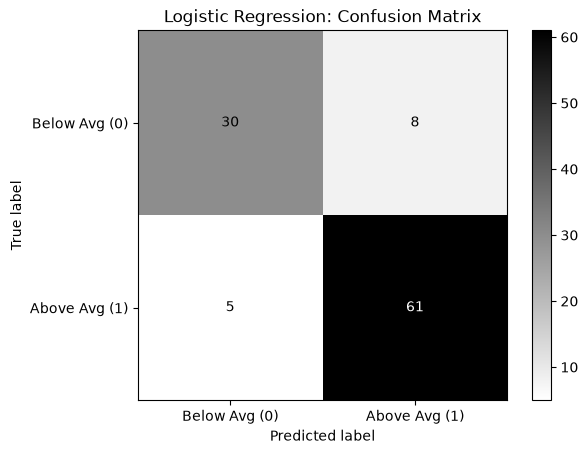

In [505]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate binary predictions
predictions_logistic = log_reg1.predict(features_test_scaled)

# Create the confusion matrix
cm = confusion_matrix(binary_target_test, predictions_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, 
    display_labels=['Below Avg (0)', 'Above Avg (1)'])

disp.plot(cmap='binary')

plt.title('Logistic Regression: Confusion Matrix')
plt.show()


### 4.2 Observations

The linear regression model achieved an R² score of 0.5716 on the test set. This means that the model explains approximately 57% of the variation in the target variable in the test data. The test MAE was 6.7069, meaning that the predictions differed from the actual house prices by approximately 6.71 units on average.

Because the features were standardized before fitting the linear regression model, the coefficient magnitudes can be compared more directly. Among the six features, the distance to the nearest MRT station (X3) had the largest absolute coefficient, while longitude (X6) had the smallest absolute coefficient. The negative coefficient for X3 indicates that, while holding the other features constant in the model, larger distances from the MRT station are associated with lower predicted house prices.

For logistic regression, the target was converted into a binary variable using the average target value calculated from the training data. The model without standardization achieved a test accuracy of 0.8654, while the standardized version achieved a test accuracy of 0.8750.

The standardized logistic regression therefore performed better in this particular test split. However, the difference is relatively small, so the result should not be interpreted as proof that standardization always improves logistic regression.

The confusion matrix and additional classification metrics provide more detailed information about the classification performance than accuracy alone. In particular, precision and recall help identify how well the model predicts the above-average-price class.

Overall, the models provide useful predictive information, but the results also indicate that there is substantial variation in house prices that is not explained by the selected features.


## 5 Evaluation

### 5.1 Linear Regression Evaluation

The linear regression model was evaluated using the previously unseen test set. Three regression metrics were used: R², Mean Squared Error (MSE), and Mean Absolute Error (MAE).

The model achieved:

* R² = 0.5716
* MSE = 81.6980
* MAE = 6.7069

The R² value indicates that approximately 57% of the variance in the target variable is explained by the model on the test set.

The MAE indicates that the model's predictions differ from the actual target values by approximately 6.71 units on average.

The actual-versus-predicted plot is also useful for evaluating how closely the predictions follow the ideal diagonal relationship. Deviations from the diagonal indicate prediction errors.



### 5.2 Logistic Regression Evaluation

The logistic regression model was evaluated on the test set using accuracy, precision, recall, and a confusion matrix.

Two versions of the model were tested. The model without standardization achieved a test accuracy of 0.8654, while the standardized version achieved a test accuracy of 0.8750.

The standardized model therefore classified the test samples more accurately for this particular train/test split. However, accuracy alone does not provide information about the types of classification errors. Therefore, the confusion matrix, precision, and recall are also considered.

The positive class represents properties whose house price of unit area is above the average calculated from the training data.


### 5.3 Comparison and Interpretation

The two models solve different prediction tasks and therefore use different evaluation metrics.

The linear regression model predicts the continuous house price of unit area. Its performance is evaluated using regression metrics such as R², MSE, and MAE.

The logistic regression model predicts whether the house price is above or below the training-set average. Its performance is evaluated using classification metrics such as accuracy, precision, recall, and the confusion matrix.

The results show that the selected features contain useful information for both tasks. However, the linear regression R² value also shows that a considerable amount of variation in house prices remains unexplained by the model.

Standardization is particularly useful when interpreting the relative magnitude of linear regression coefficients and when training the logistic regression model. In this experiment, the standardized logistic regression achieved a slightly higher test accuracy than the non-standardized version.


### 5.4 Limitations

The models have several limitations. First, the dataset contains only six input features, so other factors that may affect house prices are not included in the models.

Second, the dataset represents real estate valuations from New Taipei City, Taiwan. Therefore, the models may not generalize well to other locations or to different market conditions.

The linear regression model explains only part of the variation in the target variable, as indicated by the test R² value.

In addition, the logistic regression target is created using the average house price of the training set. Therefore, the classification threshold is specific to this dataset and training split.

For these reasons, the models should be considered predictive and educational tools rather than professional real estate valuation systems.


## 5.5 Feature Importance

### 5.5.1 Logistic Feature Importance

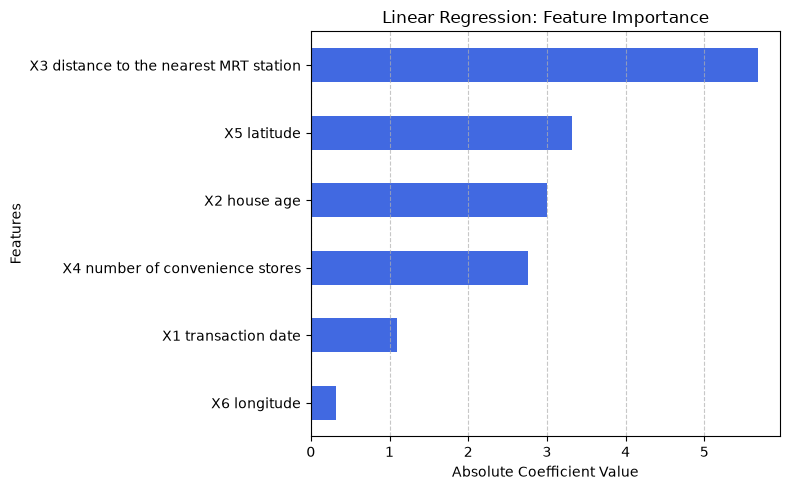

In [506]:
# Extract coefficients from the linear model and calculate absolute values
coefs = pd.DataFrame(
    model.coef_.ravel(), 
    columns=['Coefficient'], 
    index=features.columns
)
coefs['Absolute_Importance'] = coefs['Coefficient'].abs()

# Sort by absolute importance for plotting
coefs = coefs.sort_values(by='Absolute_Importance', ascending=True)

# Plot the linear feature importance
fig, ax = plt.subplots(figsize=(8, 5))
coefs['Absolute_Importance'].plot(kind='barh', color='royalblue', ax=ax)
ax.set_title("Linear Regression: Feature Importance")
ax.set_xlabel("Absolute Coefficient Value")
ax.set_ylabel("Features")
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5.5.2 Interpretation

Because the input data was standardized prior to modeling, the absolute magnitudes of the coefficients indicate each feature's relative importance. The most important feature for predicting continuous house prices is X3 (distance to the nearest MRT station), which holds the largest absolute weight (approx 5.68). Its negative coefficient indicates that house prices drop as the distance to the MRT increases. X5 (latitude) is the second most important feature, while X6 (longitude) and X1 (transaction date) have the weakest influence on the model's predictions.

### 5.5.3 Logistic Feature Importance

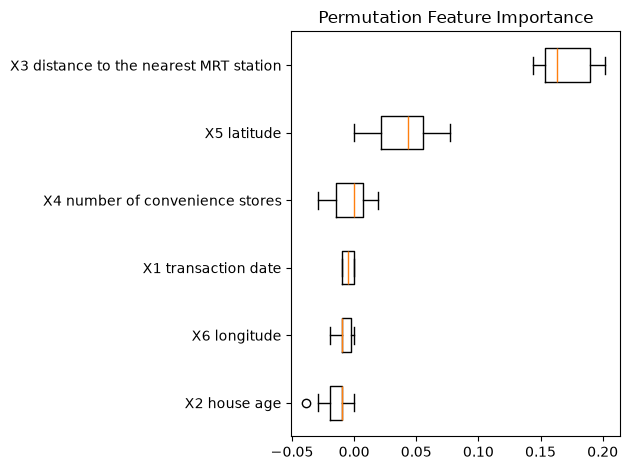

In [507]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance using the standardized model and scaled test data
result = permutation_importance(
    log_reg1, 
    features_test_scaled, 
    binary_target_test, 
    n_repeats=10, 
    scoring="accuracy", 
    random_state=0, 
    n_jobs=-1
)

# Sort features by their mean importance score
sorted_idx = result.importances_mean.argsort()

# Plot the results
fig, ax = plt.subplots()
ax.boxplot(
    result.importances[sorted_idx].T, 
    orientation="horizontal",
    tick_labels=features.columns[sorted_idx] 
)
ax.set_title("Permutation Feature Importance")
fig.tight_layout()
plt.show()


### 5.5.4 Interpretation 

Permutation importance measures how much the model's accuracy drops when a feature's values are randomly shuffled. Based on the permutation plot, X3 (distance to the nearest MRT station) is overwhelmingly the most critical feature for classifying whether a house price is above or below average. Shuffling this feature causes the steepest drop in test accuracy. X5 (latitude) and X4 (number of convenience stores) also provide positive predictive value. Conversely, X1, X2, and X6 show near-zero permutation importance, indicating the logistic model relies very little on them to make its binary classifications.

## 6 Deployment

The trained models could be used as decision-support tools for estimating real estate prices.

The linear regression model can be used when the goal is to obtain an estimated continuous house price per unit area based on the six input features.

The logistic regression model can be used when the goal is to classify a property according to whether its price is above or below the average price calculated from the training data.

Before deploying either model to new data, the same preprocessing procedure used during training must be applied. In particular, new input features must be transformed using the scaler fitted on the training data.

The models should not be considered as replacements for professional property valuation. Their predictions are based only on the variables available in this dataset and may not generalize to other locations or future market conditions.

Further development could include testing the models on additional data, monitoring their performance over time, and evaluating additional features that may explain house price variation.
